## 1. Project Overview

This project aims to build a Machine Learning model to predict median house values based on various housing features such as income, number of rooms, population, households, and geographical proximity to the ocean.

The target variable in this dataset is:  <b> median_house_value </b>

The goal is to analyze the dataset, perform feature engineering, apply regression models, and evaluate their performance using appropriate metrics.

## 2. Problem Statement

- Accurate housing price prediction is important for:
- Real estate businesses
- Property investors
- Urban planners
- Buyers and sellers

### The objective of this project is to develop a regression model that:

- Minimizes prediction error
- Generalizes well to unseen data
- Provides reliable price estimates

## 3. Dataset Description

The dataset contains both numerical and categorical features.

#### Numerical Features

- Median Income
- Total Rooms
- Total Bedrooms
- Population
- Households
- Housing Median Age

#### Categorical Feature

- Ocean Proximity

#### Target Variable

- median_house_value

## 4. Project Workflow

##### The project follows a structured Machine Learning pipeline:

- Data Loading
- Exploratory Data Analysis (EDA)
- Handling Missing Values
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Model Comparison

## 5. Exploratory Data Analysis (EDA)

#### EDA was performed to:

- Understand feature distributions
- Identify correlations
- Detect outliers
- Analyze relationships between features and target variable

## 6. Data Preprocessing

#### The following preprocessing steps were applied:
- Handling missing values
- Encoding categorical variables
- Train-test split

## 7. Models Used

#### The following regression models were implemented:

- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

In [35]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

In [36]:
# Read in the data with read_csv into pandas dataframe
housing_df = pd.read_csv('housing.csv')

In [37]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Text(0.5, 0, 'house values')

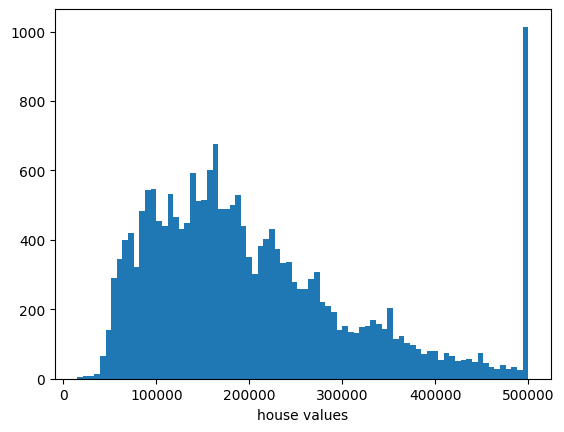

In [38]:
# Ploting the distribution of the target variable i.e. median house value using histogram

# bins = amount of columns
plt.hist(housing_df['median_house_value'] , bins=80)   
plt.xlabel("house values")

# Summary :- most of the median values are distributed normally with few outliers

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

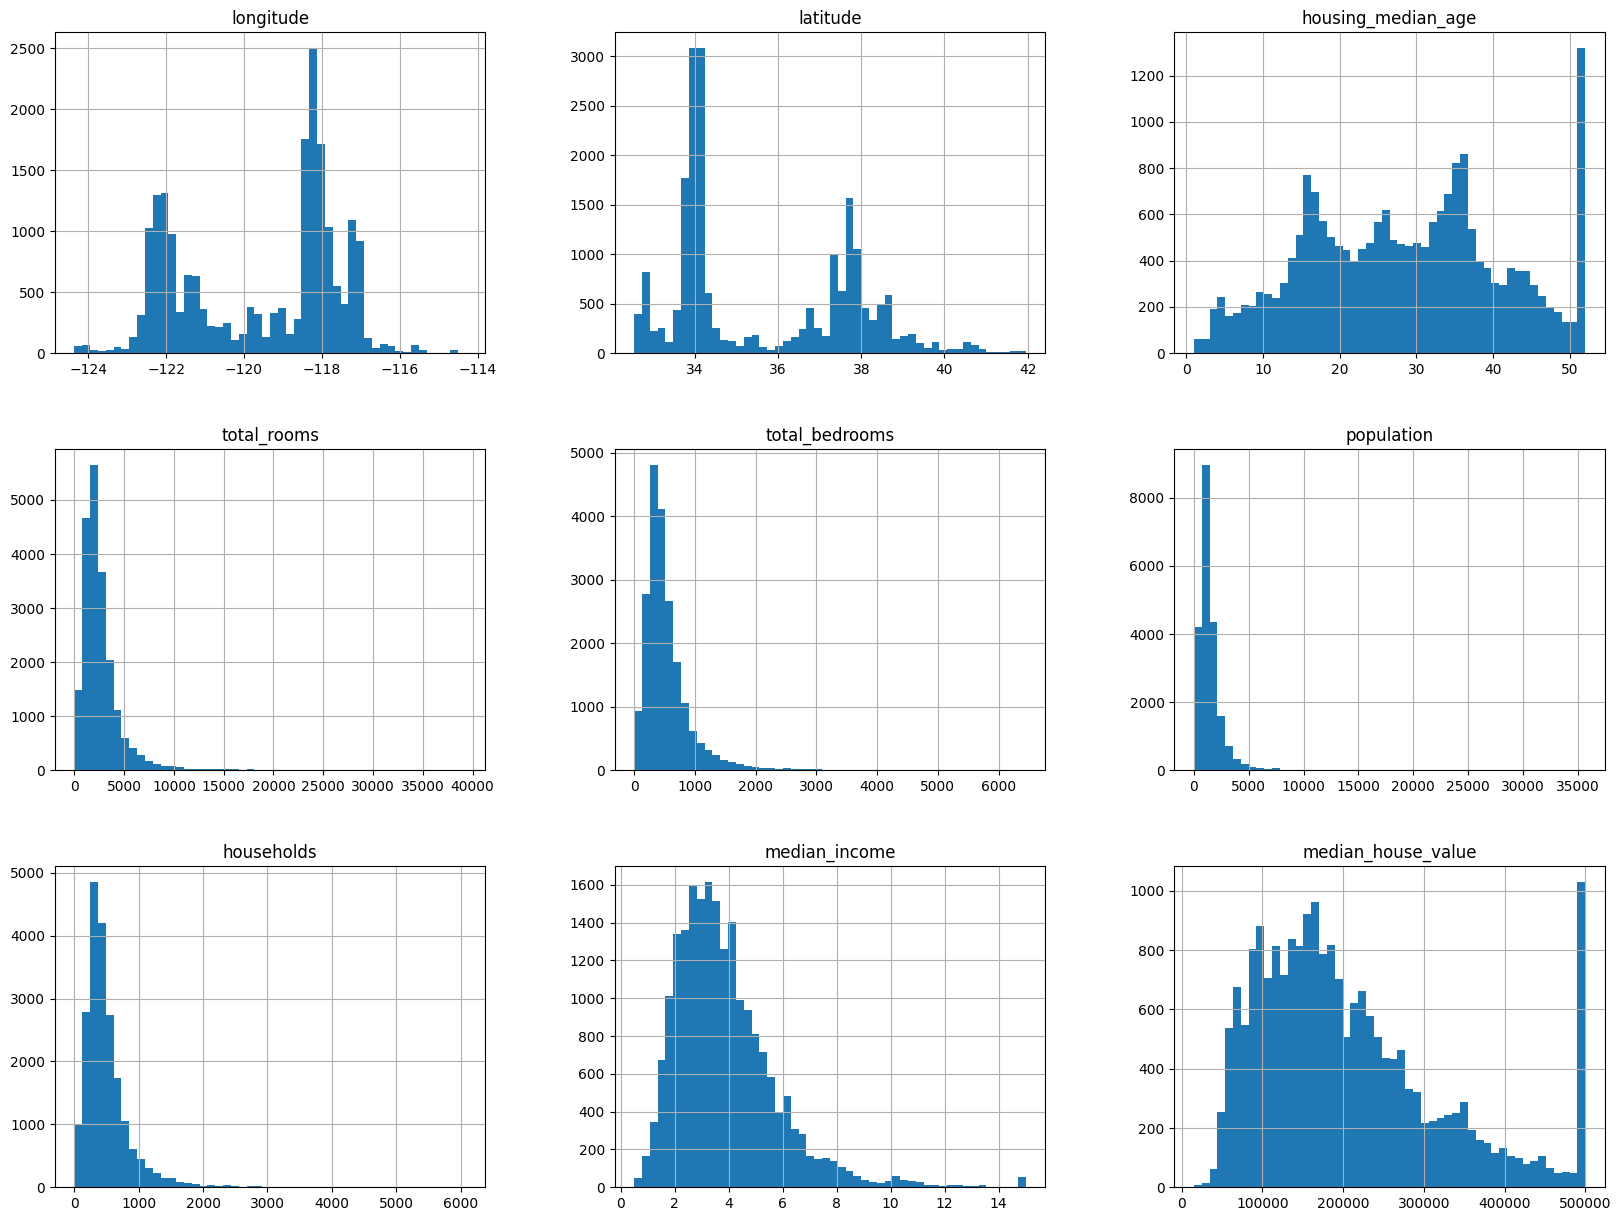

In [39]:
#  histogram for all the rest of the features that are numerical

housing_df.hist(bins=50 , figsize=(20,15))

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071035      -0.079809   
housing_

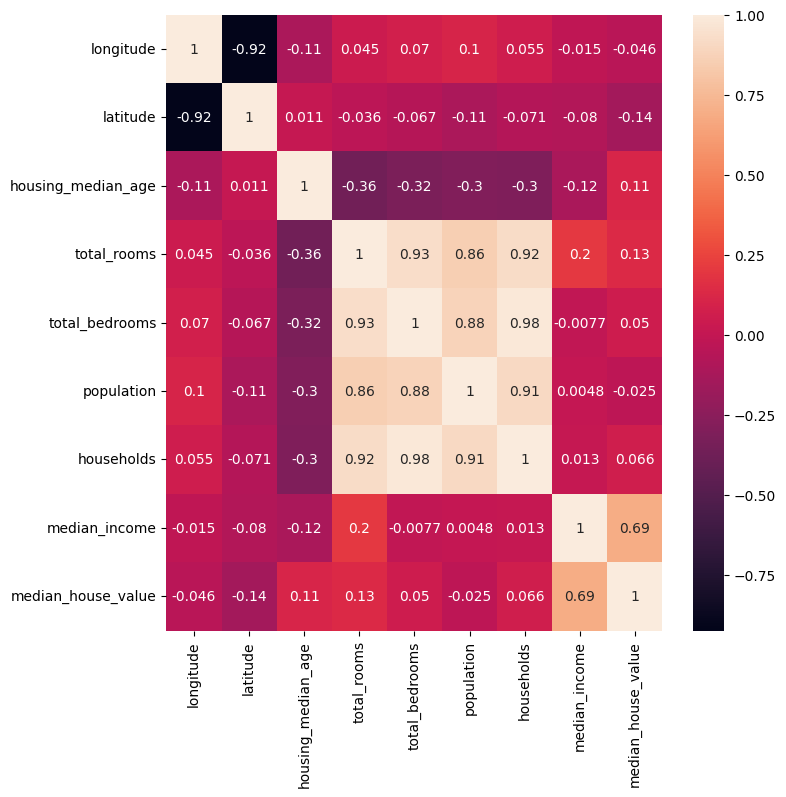

In [40]:
# HEAT MAPS :- shows the correlation matrix for each pair of columns in the dataframe

corr = housing_df.corr(numeric_only=True)
print(corr)

plt.figure(figsize= (8,8))
sns.heatmap(corr , annot=True)
plt.show()

## FEATURE ENGINEERING
- manipulate data
- adds , remove , and combines features
- create new features

=> All to improve model predictions 

### Prepare & Process Data

#### Understanding missing data

In [41]:
# finding missing data
housing_df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [42]:
# calulate the precentage of missing data
housing_df['total_bedrooms'].isnull().sum()/housing_df.shape[0] *100

np.float64(1.002906976744186)

#### use imputation to handle missing data

In [43]:
from sklearn.impute import KNNImputer

# KNN -> K-nearest neighbours
# Creating a temporary copy of the dataframe
housing_df_temp = housing_df.copy()

# retrive columns only with numeric values
column_list = [col for col in housing_df_temp.columns if housing_df_temp[col].dtype != 'object']

# extract columns that contains at least one missing value
new_column_list = [col for col in housing_df_temp.loc[: , housing_df_temp.isnull().any()]]

# update temp dataframe with numeric values that have empty values
housing_df_temp = housing_df_temp[new_column_list]
housing_df_temp

,total_bedrooms
0,129.0
1,1106.0
2,190.0
3,235.0
4,280.0
...,...
20635,374.0
20636,150.0
20637,485.0
20638,409.0


In [44]:
# initialize KNNImputer to impute missing data using ml
knn = KNNImputer(n_neighbors = 3 )
# missing value will be filled with the average of 3 nearest data points

# fit function trains the model
knn.fit(housing_df_temp)

# transform the data using the model
# applies the transformation model (i.e knn) to data
array_Values = knn.transform (housing_df_temp)

# convert tge array values to dataframe with the appropriate column names
housing_df_temp = pd.DataFrame(array_Values , columns = new_column_list)
housing_df_temp

,total_bedrooms
0,129.0
1,1106.0
2,190.0
3,235.0
4,280.0
...,...
20635,374.0
20636,150.0
20637,485.0
20638,409.0


In [45]:
# confirm there are no columns with missing values
housing_df_temp.isnull().sum()

total_bedrooms    0
dtype: int64

In [46]:
# replace old missing value column with the imputed values ccolumn

# loop through the list of columns and overlay each one
for column_name in new_column_list:
    housing_df[column_name] = housing_df_temp.replace(housing_df[column_name] , housing_df[column_name])
housing_df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

### Handling highly correlated features

In [47]:
# several features like total_rooms , total_bedrooms , population , households ..have high correlation

# a new feature that is a ratio of the total rooms to household
housing_df['rooms_per_household'] = housing_df['total_rooms']/housing_df['households']

# a new feature that is a ratio of the total bedrooms to total rooms
housing_df['bedrooms_per_room'] = housing_df['total_bedrooms']/housing_df['total_rooms']

# a new feature that is a ratio of the population to the household
housing_df['population_per_household'] = housing_df['population']/housing_df['households']

# combining latitude  and longitude into one as they have negative correlation 
housing_df['coords'] = housing_df['longitude']/housing_df['latitude']

housing_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20640 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   ocean_proximity           20640 non-null  object 
 10  rooms_per_household       20640 non-null  float64
 11  bedrooms_per_room         20640 non-null  float64
 12  population_per_household  20640 non-null  float64
 13  coords                    20640 non-null  float64
dtypes: flo

In [48]:
##  remove the comibned features now 
housing_df = housing_df.drop('total_rooms' , axis=1)
housing_df = housing_df.drop('households' , axis=1)
housing_df = housing_df.drop('total_bedrooms' , axis=1)
housing_df = housing_df.drop('population' , axis=1)
housing_df = housing_df.drop('longitude' , axis=1)
housing_df = housing_df.drop('latitude' , axis=1)

housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   housing_median_age        20640 non-null  float64
 1   median_income             20640 non-null  float64
 2   median_house_value        20640 non-null  float64
 3   ocean_proximity           20640 non-null  object 
 4   rooms_per_household       20640 non-null  float64
 5   bedrooms_per_room         20640 non-null  float64
 6   population_per_household  20640 non-null  float64
 7   coords                    20640 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.3+ MB


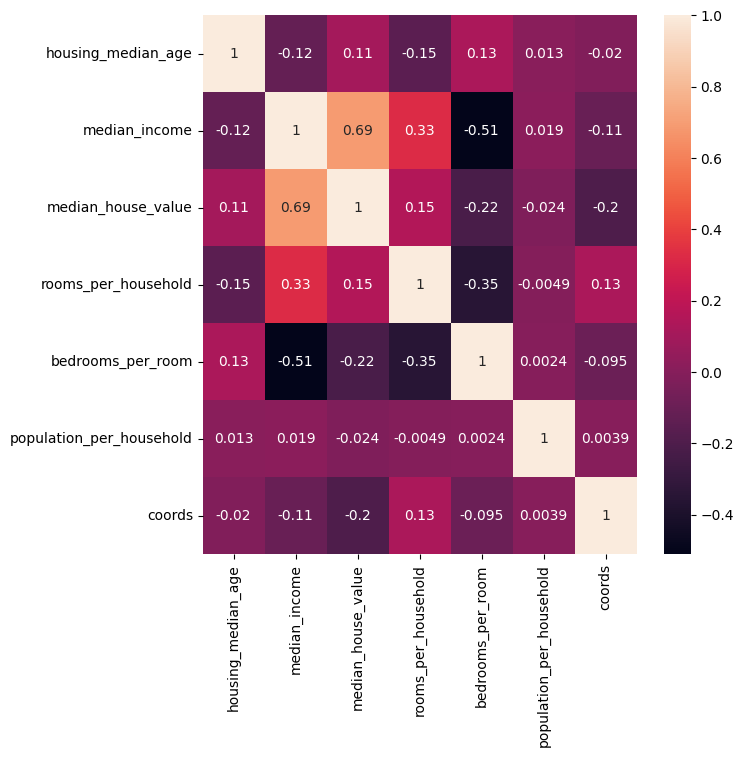

In [49]:
#  HEAT MAP after removing correlation
corr= housing_df.corr(numeric_only=True)

plt.figure(figsize= (7,7))

sns.heatmap(corr , annot=True)
plt.show()

 ### ONE HOT ENCODING -> convert categorical to numerical data




In [50]:
# unique values in ocean proximity column
housing_df.ocean_proximity.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [51]:
#  counting total values 
housing_df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [52]:
#  get_dummies working
print(pd.get_dummies(housing_df['ocean_proximity'], dtype=int))

       <1H OCEAN  INLAND  ISLAND  NEAR BAY  NEAR OCEAN
0              0       0       0         1           0
1              0       0       0         1           0
2              0       0       0         1           0
3              0       0       0         1           0
4              0       0       0         1           0
...          ...     ...     ...       ...         ...
20635          0       1       0         0           0
20636          0       1       0         0           0
20637          0       1       0         0           0
20638          0       1       0         0           0
20639          0       1       0         0           0

[20640 rows x 5 columns]


In [53]:
# replacing the ocean promixity column using get dummies()

housing_df_encoded = pd.get_dummies(data=housing_df, columns=['ocean_proximity'] , dtype=int)
housing_df_encoded.head()

,housing_median_age,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,coords,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,8.3252,452600.0,6.984127,0.146591,2.555556,-3.226769,0,0,0,1,0
1,21.0,8.3014,358500.0,6.238137,0.155797,2.109842,-3.228209,0,0,0,1,0
2,52.0,7.2574,352100.0,8.288136,0.129516,2.802260,-3.229590,0,0,0,1,0
3,52.0,5.6431,341300.0,5.817352,0.184458,2.547945,-3.229855,0,0,0,1,0
4,52.0,3.8462,342200.0,6.281853,0.172096,2.181467,-3.229855,0,0,0,1,0


### logistic Regression : -
- classification problems to predict probability
- Uses binary values (0/1 , true/false , yes/no)
- output value lie between 0 & 1

### Regression:-
- works on Regression problems
- predicts numeric values
- 3 common regression algorithm:-
  1) Linear Regression
  2) RandomForestRegressor
  3) XGBoost

## Train Model

### Linear Regression - Model Training

In [54]:
X = housing_df_encoded[['housing_median_age','median_income', 'rooms_per_household','bedrooms_per_room',
                        'population_per_household', 'coords','ocean_proximity_<1H OCEAN','ocean_proximity_INLAND',
                        'ocean_proximity_ISLAND','ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN' ]]
y = housing_df_encoded['median_house_value']

### Split training & test data

In [55]:
# we will split it into training & testing data 
# 70% for training and 10% testing
# X -> array with the input .... Y -> array with output

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train , X_test , y_train , y_test = train_test_split(X, y , random_state=42 , shuffle=True, test_size=0.3)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14448, 11)
(6192, 11)
(14448,)
(6192,)


In [56]:
# correcting column names 
X_train.columns = X_train.columns.str.replace('[', '', regex=False)
X_train.columns = X_train.columns.str.replace(']', '', regex=False)
X_train.columns = X_train.columns.str.replace('<', '', regex=False)
X_test.columns = X_test.columns.str.replace('<', '', regex=False)

In [57]:
# # use scikit-learn linearRegression to train the model pn both training & evaluate it on the test set

# from sklearn.linear_model import LinearRegression

# # create a linear regressor using all the features available 
# reg_model = LinearRegression()

# # train the model using training sets
# reg_model.fit(X_train , y_train)

In [58]:
# Run the predictions on the training and testing data
# y_pred_test = reg_model.predict(X_test)

# # Compare actual value with predicted value 
# pred_test_df = pd.DataFrame({
#     'Actual': y_test,
#     'Predicted': y_pred_test
# })
# pred_test_df

### Evaluate model using R^2 metric

In [59]:
# r2_reg_model_test = round(reg_model.score(X_test , y_test),2)
# print("R^2 Test is : {}".format(r2_reg_model_test))

## RandomForestRegressor - Model Training 

In [64]:
# from sklearn.ensemble import RandomForestRegressor

# #  create object of it
rf_model = RandomForestRegressor(n_estimators=10,random_state=10)

# # train the model
rf_model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=10, random_state=10)

In [65]:
# Run the predictions on the training and testing data
# y_rf_pred_test = rf_model.predict(X_test)

# # Compare actual value with predicted value 
# rf_pred_test_df = pd.DataFrame({
#     'Actual': y_test,
#     'Predicted': y_rf_pred_test
# })
# rf_pred_test_df

In [66]:
# detremine accuracy using R^2

# from sklearn.metrics import r2_score
# score = r2_score(y_test , y_rf_pred_test)
# print("R^2 Test is : {}".format(round(score , 2)*100))

## Determine Feature Importance 
-random forest algorithm  fives the "feature importance" for all the variables in the dataframe
-plot 6 most important feature

<Axes: >

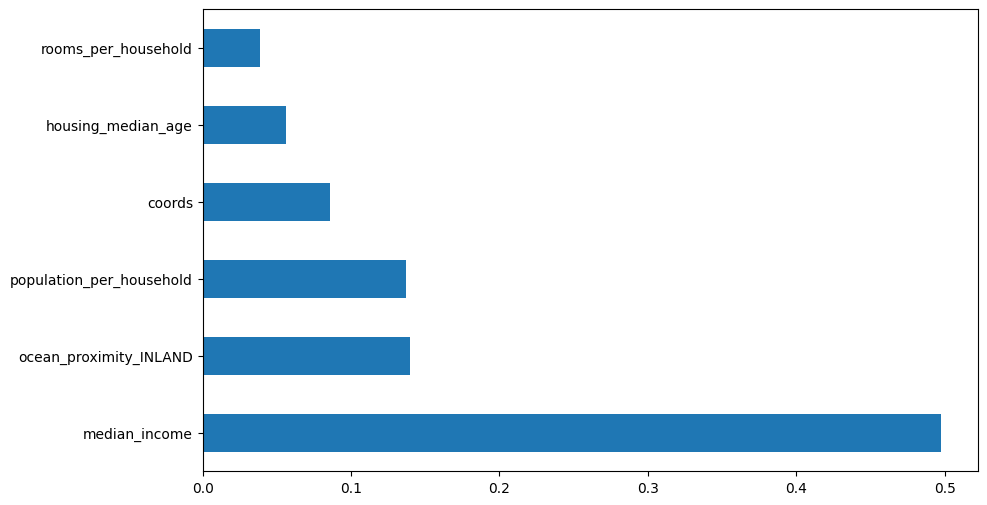

In [67]:
plt.figure(figsize=(10,6))
feat_imp = pd.Series(rf_model.feature_importances_ , index=X_train.columns)
feat_imp.nlargest(6).plot(kind='barh')

In [68]:
# now we will train our model again using only these 6 important features and observe change in RMSE values for the train and validation set
train_x_if = X_train[['bedrooms_per_room' ,'housing_median_age' ,'coords' ,'ocean_proximity_ISLAND' , 
                      'population_per_household' ,'median_income']]
test_x_if = X_test[['bedrooms_per_room' ,'housing_median_age' ,'coords' ,'ocean_proximity_ISLAND' , 
                      'population_per_household' ,'median_income']]

# creating randomforest object
rf_model_if = RandomForestRegressor(n_estimators=10 , random_state=10)

# train the model
rf_model_if.fit(train_x_if ,y_train)

# predict the target value
predict_test_with_if = rf_model_if.predict(test_x_if)

In [69]:
# Root mean squared error
# from sklearn.metrics import mean_squared_error
# print('RMSE on test data : ', mean_squared_error(y_test , predict_test_with_if)**(0.5))

## XGBoost - Model Training

In [70]:
%pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
from xgboost import XGBRegressor

# creating object
xgb_model = XGBRegressor()

# train the model
# xgb_model.fit(X_train,y_train)

In [72]:
#  predict value
# y_xgb_pred_test = xgb_model.predict(X_test)

In [73]:
# evaluate model
# Compare actual value with predicted value 
# xgb_pred_test_df = pd.DataFrame({
#     'Actual': y_test,
#     'Predicted': y_xgb_pred_test
# })
# xgb_pred_test_df

In [74]:
# detremine accuracy using R^2

# from sklearn.metrics import r2_score
# score = r2_score(y_test , y_xgb_pred_test)
# print("R^2 Test is : {}".format(round(score , 2)*100))

In [75]:
# Compare actual value with predicted value 
# xgb_2_pred_test_df = pd.DataFrame({
#     'Actual': y_test,
#     'Predicted': y_xgb_2_pred_test
# })
# xgb_2_pred_test_df

In [76]:
# detremine accuracy using R^2

# r2_xgb_model_2_test = round(xgb_model_2.score(X_test , y_test),2)
# print("R^2 Test is : {}".format(r2_xgb_model_2_test))

## Hyperparameter Tuning

In [77]:
# determine hyperparameter available tuning
xgb_model.get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [78]:
xgb_model_2 = XGBRegressor(
    gamma = 0.5,
    learning_rate=0.05,
    max_depth=6,
    n_estimators=1000,
    n_jobs=16,
    objective='reg:squarederror',
    subsample=0.8,
    scale_pos_weight=0,
    reg_alpha=0,
    reg_lambda=1,
    verbosity=1
)

xgb_model_2.fit(X_train ,y_train)

# predictions
y_xgb_2_pred_test= xgb_model_2.predict(X_test)


## Train the model in parallel using Pipeline

this code stacks multiple pipelines to find the model with the best accuracy

In [79]:
# pipelines

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

pipeline_lr = Pipeline([('lr_classifier' , LinearRegression())])
pipeline_rf = Pipeline([('rf_classifier' , RandomForestRegressor(n_estimators=10 , random_state=10))])
pipeline_xgb = Pipeline([('xgb_classifier' , XGBRegressor())])

pipelines = [pipeline_lr ,pipeline_rf ,pipeline_xgb]
pipe_dict = {0:'Linear Regression' , 1: 'Random Forest Regressor' , 2: 'XGBRegressor'}

for pipe in pipelines:
    pipe.fit(X_train , y_train)

for i,model in enumerate(pipelines):
    pred_test = model.predict(X_test)
    print("{} Test Accuracy : {}".format(pipe_dict[i] , model.score(X_test , y_test)))
    print(pd.DataFrame({'Actual' : y_test , 'Predicted' : pred_test}))
    

Linear Regression Test Accuracy : 0.5539152802688388
         Actual      Predicted
20046   47700.0  104715.540790
3024    45800.0   90644.833269
15663  500001.0  215552.381354
20484  218600.0  283365.007591
9814   278000.0  245112.099874
...         ...            ...
17505  237500.0  209304.634501
13512   67300.0   74640.438821
10842  218400.0  215452.143080
16559  119400.0  125811.202747
5786   209800.0  201373.682871

[6192 rows x 2 columns]
Random Forest Regressor Test Accuracy : 0.7584361627978977
         Actual  Predicted
20046   47700.0    53510.0
3024    45800.0    96990.0
15663  500001.0   442670.3
20484  218600.0   259180.0
9814   278000.0   246620.0
...         ...        ...
17505  237500.0   241580.1
13512   67300.0    72000.0
10842  218400.0   202330.0
16559  119400.0   129890.0
5786   209800.0   206380.0

[6192 rows x 2 columns]
XGBRegressor Test Accuracy : 0.7742896789627469
         Actual      Predicted
20046   47700.0   49648.671875
3024    45800.0   86139.742188
1

## 10. Conclusion

- The models were successfully trained and evaluated.
- Ensemble methods such as Random Forest and XGBoost generally performed better than Linear Regression.
- Feature engineering and preprocessing significantly improved model performance.